# kNN OOD split sanity checks
- Verifies row counts and disjointness
- Confirms knn_score ranges vs log output
- Checks there is no overlap with original train/val splits


In [5]:
from pathlib import Path
import json
import pandas as pd

# Paths
ID_PATH = Path("datasets/craigslist_cleaned.csv")
OOD_PATH = Path("datasets/craigslist_ood_knn.csv")
PREPROC_META = Path("outputs/trainings/training_point_m/point_m_20251211-144003_292628/preproc_meta.json")


In [6]:
# Load ID/OOD
id_df = pd.read_csv(ID_PATH, usecols=["id", "knn_score"])
ood_df = pd.read_csv(OOD_PATH, usecols=["id", "knn_score"])

print(f"ID rows: {len(id_df):,}")
print(f"OOD rows: {len(ood_df):,}")
print(f"ID knn_score range: {id_df.knn_score.min():.4f}–{id_df.knn_score.max():.4f}")
print(f"OOD knn_score range: {ood_df.knn_score.min():.4f}–{ood_df.knn_score.max():.4f}")
print(f"ID/OOD id overlap: {len(set(id_df.id.astype(str)) & set(ood_df.id.astype(str)))}")


ID rows: 126,789
OOD rows: 1,585
ID knn_score range: 0.0000–1.9096
OOD knn_score range: 2.8880–7.1313
ID/OOD id overlap: 0


In [7]:
# Quantile spot-checks against the log (expected: ID q0.80 ~2.49, OOD q0.05 ~2.97)
print("ID q0.80:", id_df.knn_score.quantile(0.80))
print("OOD q0.05:", ood_df.knn_score.quantile(0.05))


ID q0.80: 1.6306093753839774
OOD q0.05: 2.8970603307088223


In [8]:
# Check leakage vs original train/val splits
meta = json.loads(PREPROC_META.read_text())
train_ids = set(str(meta["id_values"][i]) for i in meta["splits"]["train"])
val_ids = set(str(meta["id_values"][i]) for i in meta["splits"]["val"])

id_ids = set(id_df.id.astype(str))
ood_ids = set(ood_df.id.astype(str))

print("ID overlap with train:", len(id_ids & train_ids))
print("ID overlap with val  :", len(id_ids & val_ids))
print("OOD overlap with train:", len(ood_ids & train_ids))
print("OOD overlap with val  :", len(ood_ids & val_ids))


ID overlap with train: 107554
ID overlap with val  : 6438
OOD overlap with train: 11
OOD overlap with val  : 510


In [9]:
import re
from pathlib import Path
import pandas as pd
import yaml

pat = re.compile(r"k search .*?\n(.*?)\n\[knn-ood\] choosing k=(\d+)", re.S)
id_pat = re.compile(r"wrote (\d+) rows -> .*id_knn.*")
ood_pat = re.compile(r"wrote (\d+) rows -> .*ood_knn.*")

rows = []
for path in Path("logs").glob("knn_ood_*.out"):
    text = Path(path).read_text()
    m = pat.search(text)
    if not m:
        continue
    table = m.group(1).strip().splitlines()
    chosen_k = int(m.group(2))
    gaps = []
    for line in table:
        parts = line.split()
        if len(parts) >= 3 and parts[0].isdigit():
            k = int(parts[0]); gap = float(parts[1]); std = float(parts[2])
            gaps.append((k, gap, std))
    if not gaps:
        continue
    best_gap = max(g[1] for g in gaps)
    gap_at_chosen = next((g[1] for g in gaps if g[0] == chosen_k), None)
    std_at_chosen = next((g[2] for g in gaps if g[0] == chosen_k), None)
    m_id = id_pat.search(text)
    m_ood = ood_pat.search(text)
    base = Path(path).stem.split('-')[0]
    cfg_path = Path("logs/knn_ood_configs") / f"{base}.yaml"
    proj_dim = id_q = ood_q = ref_split = cand_split = knn_list = None
    if cfg_path.exists():
        cfg = yaml.safe_load(cfg_path.read_text())
        knn_cfg = cfg.get("knn_ood", {})
        proj_dim = knn_cfg.get("proj_dim")
        id_q = knn_cfg.get("id_q")
        ood_q = knn_cfg.get("ood_q")
        ref_split = knn_cfg.get("ref_split")
        cand_split = knn_cfg.get("candidate_split")
        knn_list = knn_cfg.get("knn_k_list") or knn_cfg.get("knn_k")
    rows.append({
        "log": Path(path).name,
        "chosen_k": chosen_k,
        "best_gap": best_gap,
        "gap_at_chosen": gap_at_chosen,
        "std_at_chosen": std_at_chosen,
        "sigma": gap_at_chosen / std_at_chosen,
        "n_id": int(m_id.group(1)) if m_id else None,
        "n_ood": int(m_ood.group(1)) if m_ood else None,
        "proj_dim": proj_dim,
        "id_q": id_q,
        "ood_q": ood_q,
        "ref_split": ref_split,
        "candidate_split": cand_split,
        "knn_k_list": knn_list,
    })

df_logs = pd.DataFrame(rows)
if df_logs.empty:
    print("No knn_ood logs parsed")
else:
    display(df_logs.sort_values("best_gap", ascending=False).reset_index(drop=True))


,log,chosen_k,best_gap,gap_at_chosen,std_at_chosen,sigma,n_id,n_ood,proj_dim,id_q,ood_q,ref_split,candidate_split,knn_k_list
0,knn_ood_E-303536.out,3,0.978439,0.978439,0.519461,1.883566,126789,1585,128,"[0.0, 0.8]","[0.99, 1.0]",train,all,"[3, 5, 8, 12]"
1,knn_ood_D-303535.out,3,0.943644,0.943644,0.509304,1.852811,126789,1585,96,"[0.0, 0.8]","[0.99, 1.0]",train,all,"[3, 5, 8, 12]"
2,knn_ood_C-303534.out,3,0.911645,0.911645,0.495077,1.841421,126789,1585,64,"[0.0, 0.8]","[0.99, 1.0]",train,all,"[3, 5, 8, 12]"
3,knn_ood_B-303533.out,3,0.911645,0.911645,0.495077,1.841421,126789,1585,64,"[0.0, 0.8]","[0.99, 1.0]",train,all,"[3, 5, 8, 12]"


In [11]:
from sklearn.metrics import roc_auc_score

# AUROC of knn_score for ID vs OOD using current CSVs
a = pd.read_csv('datasets/craigslist_cleaned.csv', usecols=['knn_score'])
b = pd.read_csv('datasets/craigslist_ood_knn.csv', usecols=['knn_score'])
scores = pd.concat([a, b], ignore_index=True)['knn_score'].to_numpy()
labels = [0]*len(a) + [1]*len(b)
print('AUROC(knn_score, ID vs OOD):', roc_auc_score(labels, scores))


AUROC(knn_score, ID vs OOD): 1.0


In [ ]:
import pandas as pd

id_scores = pd.read_csv('datasets/craigslist_id_knn.csv', usecols=['knn_score'])['knn_score'].to_numpy()
ood_scores = pd.read_csv('datasets/craigslist_ood_knn.csv', usecols=['knn_score'])['knn_score'].to_numpy()

print('ID range:', id_scores.min(), id_scores.max())
print('OOD range:', ood_scores.min(), ood_scores.max())
print('Do ranges overlap? ', id_scores.max() >= ood_scores.min())
print('ID q0.95:', pd.Series(id_scores).quantile(0.95))
print('OOD q0.05:', pd.Series(ood_scores).quantile(0.05))


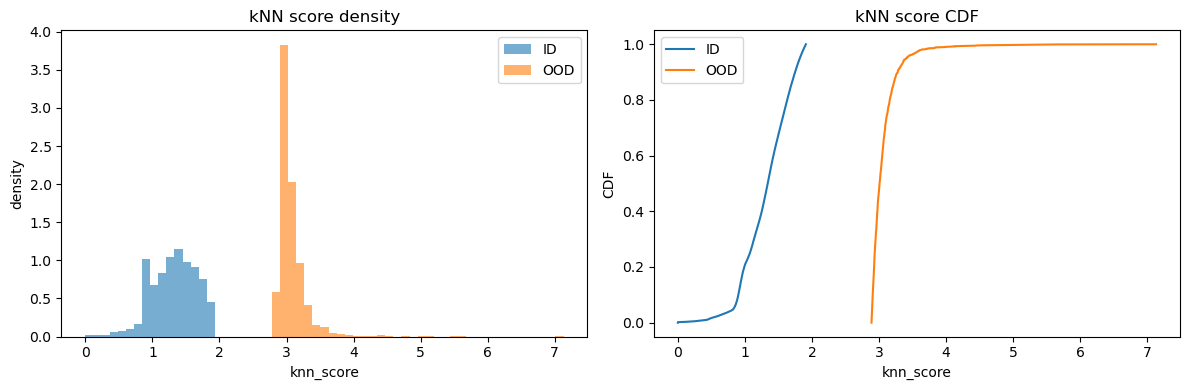

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

id_scores = pd.read_csv('datasets/craigslist_cleaned.csv', usecols=['knn_score'])['knn_score'].to_numpy()
ood_scores = pd.read_csv('datasets/craigslist_ood_knn.csv', usecols=['knn_score'])['knn_score'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PDF (histogram)
bins = np.linspace(min(id_scores.min(), ood_scores.min()),
                   max(id_scores.max(), ood_scores.max()), 60)
axes[0].hist(id_scores, bins=bins, density=True, alpha=0.6, label='ID')
axes[0].hist(ood_scores, bins=bins, density=True, alpha=0.6, label='OOD')
axes[0].set_title('kNN score density')
axes[0].set_xlabel('knn_score'); axes[0].set_ylabel('density')
axes[0].legend()

# CDF
id_sorted = np.sort(id_scores)
ood_sorted = np.sort(ood_scores)
axes[1].plot(id_sorted, np.linspace(0,1,len(id_sorted)), label='ID')
axes[1].plot(ood_sorted, np.linspace(0,1,len(ood_sorted)), label='OOD')
axes[1].set_title('kNN score CDF')
axes[1].set_xlabel('knn_score'); axes[1].set_ylabel('CDF')
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
id_scores.shape

(126789,)